### Introduction

During their lifetime, aircraft components
are susceptible to degradation, which affects
directly their reliability and performance.
This machine learning project will be directed to provide a framework for predict-
ing the aircraft’s remaining useful life (RUL)
based on the entire life cycle data in order
to provide the necessary maintenance behavior. Diverse regression, classification
models (KNN, Naïve Bayes, Random Forest,
SVM, etc..) are deployed and tested on the
NASA’s C-MAPSS data-set to assess the
engine’s lifetime. Please check the report for more theoretical details

<div align='center' > <img src='https://i.postimg.cc/gcvWCNHf/Turbofan-operation-lbp.png'>
 </div>

<div align='center' > Illustration of a turbofan engine </div>

In [1]:
# ==============================================================================
# SECTION 1 (Corrected): IMPORTS, LOADING, & SINGLE DATASET PREP
# ==============================================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# --- 1.1: Data Loading ---
print("--- Loading Data ---")
cols = ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
train_df = pd.read_csv('../input/nasa-cmaps/CMaps/train_FD001.txt',sep='\s+',header=None,index_col=False,names=cols)
test_df = pd.read_csv('../input/nasa-cmaps/CMaps/test_FD001.txt',sep='\s+',header=None,index_col=False,names=cols)
rul_df = pd.read_csv('../input/nasa-cmaps/CMaps/RUL_FD001.txt',header=None,names=['RUL'])
print("Files loaded successfully.")

# --- 1.2: RUL Calculation & Scaling ---
print("\n--- Preprocessing Data ---")
max_cycles = train_df.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycles']
train_df = pd.merge(train_df, max_cycles, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycles'] - train_df['time_cycles']
train_df = train_df.drop('max_cycles', axis=1)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
test_df[sensor_cols] = scaler.transform(test_df[sensor_cols])
print("RUL calculated and data scaled.")

# --- 1.3: Windowing Function ---
def create_windows(df, window_size, is_test=False):
    data_windows, data_rul = [], []
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit]
        if is_test:
            if len(unit_df) < window_size:
                pad_rows = window_size - len(unit_df)
                padded_data = np.pad(unit_df[sensor_cols].values, ((pad_rows, 0), (0, 0)), 'edge')
                data_windows.append(padded_data)
            else:
                data_windows.append(unit_df[sensor_cols].iloc[-window_size:].values)
        else:
            for i in range(len(unit_df) - window_size + 1):
                data_windows.append(unit_df[sensor_cols].iloc[i:i+window_size].values)
                data_rul.append(unit_df['RUL'].iloc[i+window_size-1])
    
    if is_test:
        return np.array(data_windows)
    else:
        return np.array(data_windows), np.array(data_rul)

# --- 1.4: Create ONE Dataset (Train & Test) ---
print("\n--- Creating One Windowed Dataset (window=30) ---")
window_size = 30
X_train_full, y_train_full = create_windows(train_df, window_size)
X_test_full = create_windows(test_df, window_size, is_test=True)
y_test = rul_df['RUL'].values
print("Dataset created.")

# --- 1.5: Split Dataset for Meta-Learning ---
print("\n--- Splitting Dataset for Stacking (Base vs. Meta) ---")
test_size_meta = 0.3 # Using 30% of data to train the meta-learner

X_base, X_meta, y_base, y_meta = train_test_split(X_train_full, y_train_full, test_size=test_size_meta, random_state=42)

print(f"Shape of X_base (for training specialists): {X_base.shape}")
print(f"Shape of X_meta (for training meta-learner): {X_meta.shape}")
print("Data splitting complete. Ready for model training.")

--- Loading Data ---
Files loaded successfully.

--- Preprocessing Data ---
RUL calculated and data scaled.

--- Creating One Windowed Dataset (window=30) ---
Dataset created.

--- Splitting Dataset for Stacking (Base vs. Meta) ---
Shape of X_base (for training specialists): (12411, 30, 21)
Shape of X_meta (for training meta-learner): (5320, 30, 21)
Data splitting complete. Ready for model training.


In [2]:
train_df.shape

(20631, 27)

In [3]:
# ==============================================================================
# SECTION 2: BASE MODEL (EEGNET) DEFINITION
# ==============================================================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Activation, BatchNormalization, Dropout, DepthwiseConv2D, SeparableConv2D, AveragePooling2D, Flatten, Reshape

def create_eegnet_base_model(input_shape, learning_rate_optimizer=0.001):
    """
    Creates an EEGNet model instance.
    - input_shape: Will be (window_size, num_features), e.g., (20, 21)
    """
    input_layer = Input(shape=input_shape)
    reshaped_input = Reshape((input_shape[0], input_shape[1], 1))(input_layer)

    # Block 1
    block1 = Conv2D(16, (1, 10), padding='same', use_bias=False)(reshaped_input)
    block1 = BatchNormalization()(block1)
    block1 = DepthwiseConv2D((input_shape[0], 1), use_bias=False, depth_multiplier=2)(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 2))(block1)
    block1 = Dropout(0.5)(block1)

    # Block 2
    block2 = SeparableConv2D(32, (1, 4), padding='same', use_bias=False)(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 2))(block2)
    block2 = Dropout(0.5)(block2)

    # Output Block
    flatten_layer = Flatten()(block2)
    output_layer = Dense(1, activation='linear')(flatten_layer) 
    
    model = Model(inputs=input_layer, outputs=output_layer)
    
    # We will compile the model separately after creating it,
    # so we can assign different loss functions.
    return model

print("EEGNet model-building function is defined.")

EEGNet model-building function is defined.


In [4]:
# ==============================================================================
# SECTION 3 (Corrected): TRAIN THE 3 SPECIALIST BASE MODELS
# ==============================================================================
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

# --- Hyperparameters for training ---
epochs = 50
batch_size = 128
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
input_shape = (window_size, len(sensor_cols)) # Single, consistent input shape

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=0.00001)

# --- 3.1: Train Specialist 1 (MSE Loss) ---
print("\n--- Training Specialist 1 (Loss=MSE) ---")
cp_1 = ModelCheckpoint('model_1_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
model_1 = create_eegnet_base_model(input_shape)
model_1.compile(loss='mean_squared_error', optimizer=optimizer, metrics=[tf.keras.metrics.RootMeanSquaredError()])

model_1.fit(X_base, y_base,  # <-- Using common X_base, y_base
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping, reduce_lr, cp_1],
            verbose=1)

# --- 3.2: Train Specialist 2 (MAE Loss) ---
print("\n--- Training Specialist 2 (Loss=MAE) ---")
cp_2 = ModelCheckpoint('model_2_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
model_2 = create_eegnet_base_model(input_shape)
model_2.compile(loss='mean_absolute_error', optimizer=optimizer, metrics=[tf.keras.metrics.RootMeanSquaredError()])

model_2.fit(X_base, y_base,  # <-- Using common X_base, y_base
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping, reduce_lr, cp_2],
            verbose=1)

# --- 3.3: Train Specialist 3 (Huber Loss) ---
print("\n--- Training Specialist 3 (Loss=Huber) ---")
cp_3 = ModelCheckpoint('model_3_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
model_3 = create_eegnet_base_model(input_shape)
model_3.compile(loss='huber_loss', optimizer=optimizer, metrics=[tf.keras.metrics.RootMeanSquaredError()])

model_3.fit(X_base, y_base,  # <-- Using common X_base, y_base
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping, reduce_lr, cp_3],
            verbose=1)

print("\nAll 3 specialist base models have been trained and saved.")


--- Training Specialist 1 (Loss=MSE) ---
Epoch 1/50
78/78 [==============================] - 9s 8ms/step - loss: 11291.5713 - root_mean_squared_error: 106.2618 - val_loss: 12403.9492 - val_root_mean_squared_error: 111.3730
Epoch 2/50
78/78 [==============================] - 0s 4ms/step - loss: 8774.8232 - root_mean_squared_error: 93.6740 - val_loss: 11523.2588 - val_root_mean_squared_error: 107.3464
Epoch 3/50
78/78 [==============================] - 0s 4ms/step - loss: 6378.5273 - root_mean_squared_error: 79.8657 - val_loss: 10032.5557 - val_root_mean_squared_error: 100.1626
Epoch 4/50
78/78 [==============================] - 0s 4ms/step - loss: 4292.2021 - root_mean_squared_error: 65.5149 - val_loss: 7397.3018 - val_root_mean_squared_error: 86.0076
Epoch 5/50
78/78 [==============================] - 0s 4ms/step - loss: 2838.5383 - root_mean_squared_error: 53.2779 - val_loss: 4565.4995 - val_root_mean_squared_error: 67.5685
Epoch 6/50
78/78 [==============================] - 0s 4ms/s

In [5]:
# ==============================================================================
# SECTION 3.5: (OPTIONAL) LOAD MODELS FROM CHECKPOINTS
# ==============================================================================
from tensorflow.keras.models import load_model

print("\n--- Loading saved specialist models from checkpoints ---")

# We need to specify the custom objects (like 'huber_loss') 
# if they aren't standard 'mse' or 'mae'
# However, Keras usually saves the optimizer and loss config.
# If you get an error loading model_3, uncomment the line below:
# model_3 = load_model('model_3_best.keras', custom_objects={'huber_loss': tf.keras.losses.Huber()})

model_1 = load_model('model_1_best.keras')
model_2 = load_model('model_2_best.keras')
model_3 = load_model('model_3_best.keras')

print("All 3 specialist models have been loaded from saved files.")


--- Loading saved specialist models from checkpoints ---
All 3 specialist models have been loaded from saved files.


In [6]:
# ==============================================================================
# SECTION 4 (Corrected): TRAIN THE META-LEARNER
# ==============================================================================

print("\n--- Generating Meta-Dataset ---")
# Get predictions from each specialist on the common X_meta
preds_1_meta = model_1.predict(X_meta)
preds_2_meta = model_2.predict(X_meta)
preds_3_meta = model_3.predict(X_meta)

# Stack these predictions into a new dataset
X_meta_train = np.c_[preds_1_meta.flatten(), preds_2_meta.flatten(), preds_3_meta.flatten()]
y_meta_target = y_meta # Use the common y_meta

print(f"Shape of Meta-Training set: {X_meta_train.shape}")
print(f"Shape of Meta-Target set: {y_meta_target.shape}")

# --- 4.1: Train Linear Regression Meta-Learner ---
print("\n--- Training Linear Regression Meta-Learner ---")
meta_learner_lr = LinearRegression()
meta_learner_lr.fit(X_meta_train, y_meta_target)

print("Linear Regression Meta-Learner trained.")
print(f"Learned Weights (Coefficients):")
print(f"  - Model 1 (MSE): {meta_learner_lr.coef_[0]:.4f}")
print(f"  - Model 2 (MAE): {meta_learner_lr.coef_[1]:.4f}")
print(f"  - Model 3 (Huber): {meta_learner_lr.coef_[2]:.4f}")

# --- 4.2: Train Random Forest Meta-Learner ---
print("\n--- Training Random Forest Meta-Learner ---")
meta_learner_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
meta_learner_rf.fit(X_meta_train, y_meta_target)
print("Random Forest Meta-Learner trained.")


--- Generating Meta-Dataset ---
Shape of Meta-Training set: (5320, 3)
Shape of Meta-Target set: (5320,)

--- Training Linear Regression Meta-Learner ---
Linear Regression Meta-Learner trained.
Learned Weights (Coefficients):
  - Model 1 (MSE): 1.1558
  - Model 2 (MAE): 0.1134
  - Model 3 (Huber): -0.9979

--- Training Random Forest Meta-Learner ---
Random Forest Meta-Learner trained.



--- Creating Meta-Test set for Final Evaluation ---
Shape of Meta-Test set: (100, 3)

--- Final Result (Linear Regression Meta-Learner) ---
Stacked Ensemble RMSE: 24.6525

--- Final Result (Random Forest Meta-Learner) ---
Stacked Ensemble RMSE: 27.1972


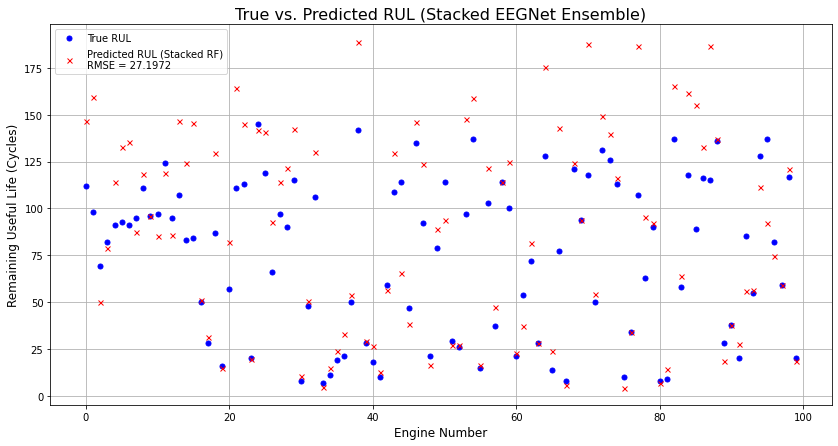

In [7]:
# ==============================================================================
# SECTION 5 (Corrected): FINAL EVALUATION & VISUALIZATION
# ==============================================================================

print("\n--- Creating Meta-Test set for Final Evaluation ---")
# 1. Get predictions from each specialist on the common TEST data
preds_1_test = model_1.predict(X_test_full)
preds_2_test = model_2.predict(X_test_full)
preds_3_test = model_3.predict(X_test_full)

# 2. Stack the test predictions
X_meta_test = np.c_[preds_1_test.flatten(), preds_2_test.flatten(), preds_3_test.flatten()]

print(f"Shape of Meta-Test set: {X_meta_test.shape}")

# --- 5.1: Evaluate with Linear Regression Meta-Learner ---
final_predictions_lr = meta_learner_lr.predict(X_meta_test)
final_rmse_lr = np.sqrt(mean_squared_error(y_test, final_predictions_lr))
print("\n--- Final Result (Linear Regression Meta-Learner) ---")
print(f"Stacked Ensemble RMSE: {final_rmse_lr:.4f}")

# --- 5.2: Evaluate with Random Forest Meta-Learner ---
final_predictions_rf = meta_learner_rf.predict(X_meta_test)
final_rmse_rf = np.sqrt(mean_squared_error(y_test, final_predictions_rf))
print("\n--- Final Result (Random Forest Meta-Learner) ---")
print(f"Stacked Ensemble RMSE: {final_rmse_rf:.4f}")

# --- 5.3: Visualize the best model's predictions ---
final_predictions = final_predictions_rf # Assume RF is better
final_rmse = final_rmse_rf

plt.figure(figsize=(14, 7))
plt.plot(y_test, label='True RUL', color='blue', marker='o', linestyle='', markersize=5)
plt.plot(final_predictions, label=f'Predicted RUL (Stacked RF)\nRMSE = {final_rmse:.4f}', color='red', marker='x', linestyle='', markersize=5)
plt.title('True vs. Predicted RUL (Stacked EEGNet Ensemble)', fontsize=16)
plt.xlabel('Engine Number', fontsize=12)
plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig('stacked_ensemble_results.png', dpi=300)
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

print("\n--- Training Linear Regression Meta-Learner ---")

# 1. Initialize the model
meta_learner_lr = LinearRegression()

# 2. Train the model
meta_learner_lr.fit(X_meta_train, y_meta_target)

# 3. Print the learned weights
print("Linear Regression Meta-Learner trained.")
print(f"Learned Weights (Coefficients):")
print(f"  - Model 1 (MSE): {meta_learner_lr.coef_[0]:.4f}")
print(f"  - Model 2 (MAE): {meta_learner_lr.coef_[1]:.4f}")
print(f"  - Model 3 (Huber): {meta_learner_lr.coef_[2]:.4f}")

# 4. Evaluate the model
final_predictions_lr = meta_learner_lr.predict(X_meta_test)
final_rmse_lr = np.sqrt(mean_squared_error(y_test, final_predictions_lr))

print(f"Final Stacked Ensemble RMSE (with Linear Regression): {final_rmse_lr:.4f}")


--- Training Linear Regression Meta-Learner ---
Linear Regression Meta-Learner trained.
Learned Weights (Coefficients):
  - Model 1 (MSE): 1.1558
  - Model 2 (MAE): 0.1134
  - Model 3 (Huber): -0.9979
Final Stacked Ensemble RMSE (with Linear Regression): 24.6525


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

print("\n--- Training Random Forest Meta-Learner ---")

# 1. Initialize the model
meta_learner_rf = RandomForestRegressor(n_estimators=100,     # 100 trees
                                      random_state=42,      # For reproducible results
                                      n_jobs=-1)          # Use all available CPU cores

# 2. Train the model
meta_learner_rf.fit(X_meta_train, y_meta_target)

# 3. Evaluate the model
final_predictions_rf = meta_learner_rf.predict(X_meta_test)
final_rmse_rf = np.sqrt(mean_squared_error(y_test, final_predictions_rf))

print(f"Final Stacked Ensemble RMSE (with Random Forest): {final_rmse_rf:.4f}")


--- Training Random Forest Meta-Learner ---
Final Stacked Ensemble RMSE (with Random Forest): 27.1972


In [10]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

print("\n--- Training XGBoost Meta-Learner ---")

# 1. Initialize the model
meta_learner_xgb = xgb.XGBRegressor(objective='reg:squarederror',
                                  n_estimators=500,       # Number of trees
                                  learning_rate=0.05,     # How much each tree contributes
                                  max_depth=4,            # Depth of each tree
                                  early_stopping_rounds=10) # Stop if validation loss doesn't improve

# 2. Train the model
# We use X_meta_train for both training and validation here
meta_learner_xgb.fit(X_meta_train, y_meta_target,
                     eval_set=[(X_meta_train, y_meta_target)],
                     verbose=False)

# 3. Evaluate the model
final_predictions_xgb = meta_learner_xgb.predict(X_meta_test)
final_rmse_xgb = np.sqrt(mean_squared_error(y_test, final_predictions_xgb))

print(f"Final Stacked Ensemble RMSE (with XGBoost): {final_rmse_xgb:.4f}")


--- Training XGBoost Meta-Learner ---
Final Stacked Ensemble RMSE (with XGBoost): 25.3094


In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

print("\n--- Training K-Neighbors Regressor (KNN) Meta-Learner ---")

# 1. Initialize the model
# We'll use 7 neighbors, a common choice. You can experiment with this value.
meta_learner_knn = KNeighborsRegressor(n_neighbors=7, n_jobs=-1)

# 2. Train the model
meta_learner_knn.fit(X_meta_train, y_meta_target)

# 3. Evaluate the model
final_predictions_knn = meta_learner_knn.predict(X_meta_test)
final_rmse_knn = np.sqrt(mean_squared_error(y_test, final_predictions_knn))

print(f"Final Stacked Ensemble RMSE (with KNN): {final_rmse_knn:.4f}")


--- Training K-Neighbors Regressor (KNN) Meta-Learner ---
Final Stacked Ensemble RMSE (with KNN): 26.1930


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

print("\n--- Training Decision Tree Meta-Learner ---")

# 1. Initialize the model
# We set max_depth to prevent the tree from overfitting, which is a major risk.
meta_learner_dt = DecisionTreeRegressor(max_depth=5, random_state=42)

# 2. Train the model
meta_learner_dt.fit(X_meta_train, y_meta_target)

# 3. Evaluate the model
final_predictions_dt = meta_learner_dt.predict(X_meta_test)
final_rmse_dt = np.sqrt(mean_squared_error(y_test, final_predictions_dt))

print(f"Final Stacked Ensemble RMSE (with Decision Tree): {final_rmse_dt:.4f}")


--- Training Decision Tree Meta-Learner ---
Final Stacked Ensemble RMSE (with Decision Tree): 25.0894
